In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_excel("Data IKM Magang.xlsx")

df.head()

,No,Tanggal,Persyaratan,Prosedur pelayanan,Waktu,Biaya/tarif,Produk pelayanan,Kompetensi/kemampuan,Perilaku petugas sopan dan ramah,Kualitas sarana dan prasarana,Penanganan pengaduan,IKM Konversi,Jumlah Orang
0,1,2023-01-01,"3,80","3,76","3,99","3,77","4,00","3,81","3,81","3,89","3,80","96,19",277
1,2,2023-02-01,"3,92","3,92","3,88","4,00","3,92","3,96","3,88","3,83","3,96","97,92",24
2,3,2023-03-01,"3,57","3,59","3,54","4,00","3,54","3,54","3,59","3,51","3,53","90,01",189
3,4,2023-04-01,"3,74","3,74","3,69","4,00","3,68","3,71","3,78","3,69","3,68","93,64",114
4,5,2023-05-01,"3,58","3,56","3,55","4,00","3,48","3,51","3,56","3,43","3,44","89,16",227


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   No                                37 non-null     int64         
 1   Tanggal                           37 non-null     datetime64[ns]
 2   Persyaratan                       37 non-null     object        
 3   Prosedur pelayanan                37 non-null     object        
 4   Waktu                             37 non-null     object        
 5   Biaya/tarif                       37 non-null     object        
 6   Produk pelayanan                  37 non-null     object        
 7   Kompetensi/kemampuan              37 non-null     object        
 8   Perilaku petugas sopan dan ramah  37 non-null     object        
 9   Kualitas sarana dan prasarana     37 non-null     object        
 10  Penanganan pengaduan              37 non-null     ob

In [4]:
kolom_numerik = [
    'Persyaratan',
    'Prosedur pelayanan',
    'Waktu',
    'Biaya/tarif',
    'Produk pelayanan',
    'Kompetensi/kemampuan',
    'Perilaku petugas sopan dan ramah',
    'Kualitas sarana dan prasarana',
    'Penanganan pengaduan',
    'IKM Konversi'
]

for col in kolom_numerik:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

In [5]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

In [6]:
print(df.isnull().sum())

No                                  0
Tanggal                             0
Persyaratan                         0
Prosedur pelayanan                  0
Waktu                               0
Biaya/tarif                         0
Produk pelayanan                    0
Kompetensi/kemampuan                0
Perilaku petugas sopan dan ramah    0
Kualitas sarana dan prasarana       0
Penanganan pengaduan                0
IKM Konversi                        0
Jumlah Orang                        0
dtype: int64


In [7]:
df.describe()

,No,Tanggal,Persyaratan,Prosedur pelayanan,Waktu,Biaya/tarif,Produk pelayanan,Kompetensi/kemampuan,Perilaku petugas sopan dan ramah,Kualitas sarana dan prasarana,Penanganan pengaduan,IKM Konversi
count,37.000000,37,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.00000
mean,19.000000,2024-07-01 08:25:56.756756736,3.881351,3.874865,3.864324,3.993784,3.871892,3.871351,3.883243,3.853514,3.872162,97.13000
min,1.000000,2023-01-01 00:00:00,3.570000,3.560000,3.540000,3.770000,3.480000,3.510000,3.480000,3.430000,3.440000,89.16000
25%,10.000000,2023-10-01 00:00:00,3.830000,3.840000,3.800000,4.000000,3.810000,3.810000,3.830000,3.790000,3.810000,96.05000
50%,19.000000,2024-07-01 00:00:00,3.920000,3.910000,3.890000,4.000000,3.920000,3.930000,3.930000,3.920000,3.930000,98.37000
75%,28.000000,2025-04-01 00:00:00,3.960000,3.940000,3.950000,4.000000,3.960000,3.960000,3.980000,3.960000,3.970000,99.04000
max,37.000000,2026-01-01 00:00:00,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,99.90000
std,10.824355,NaN,0.113043,0.110971,0.121782,0.037812,0.128773,0.123584,0.132519,0.147539,0.139366,2.72762


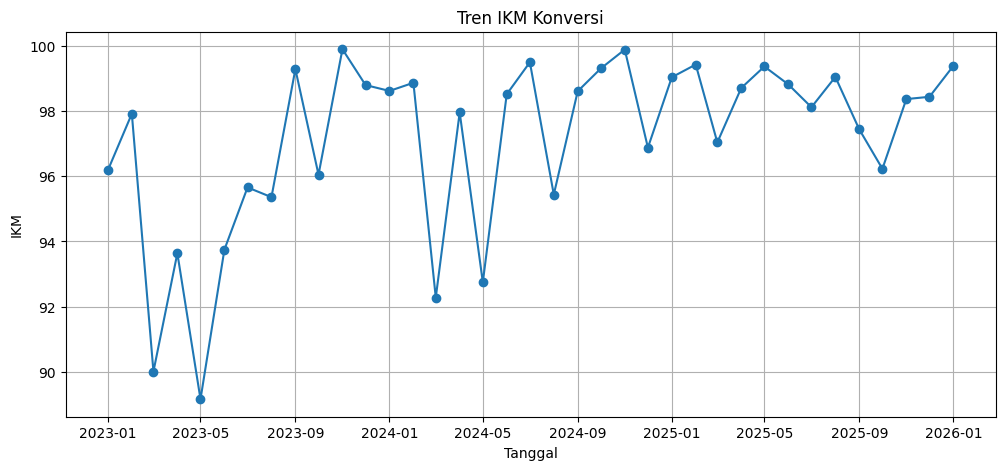

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Tanggal'],
    df['IKM Konversi'],
    marker='o'
)

plt.title('Tren IKM Konversi')
plt.xlabel('Tanggal')
plt.ylabel('IKM')
plt.grid(True)

plt.show()

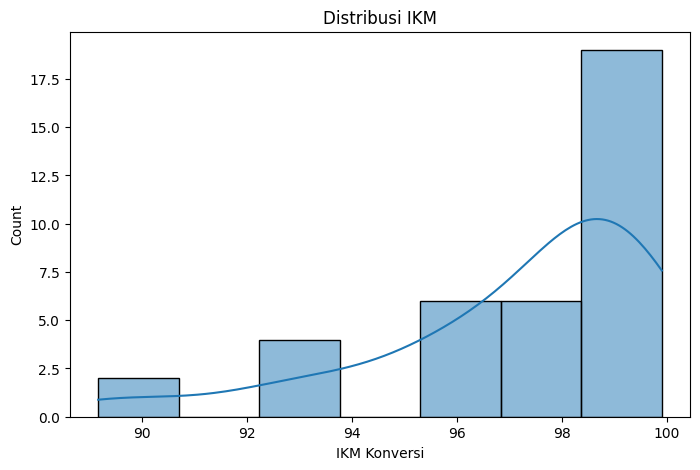

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['IKM Konversi'],
    kde=True
)

plt.title('Distribusi IKM')
plt.show()

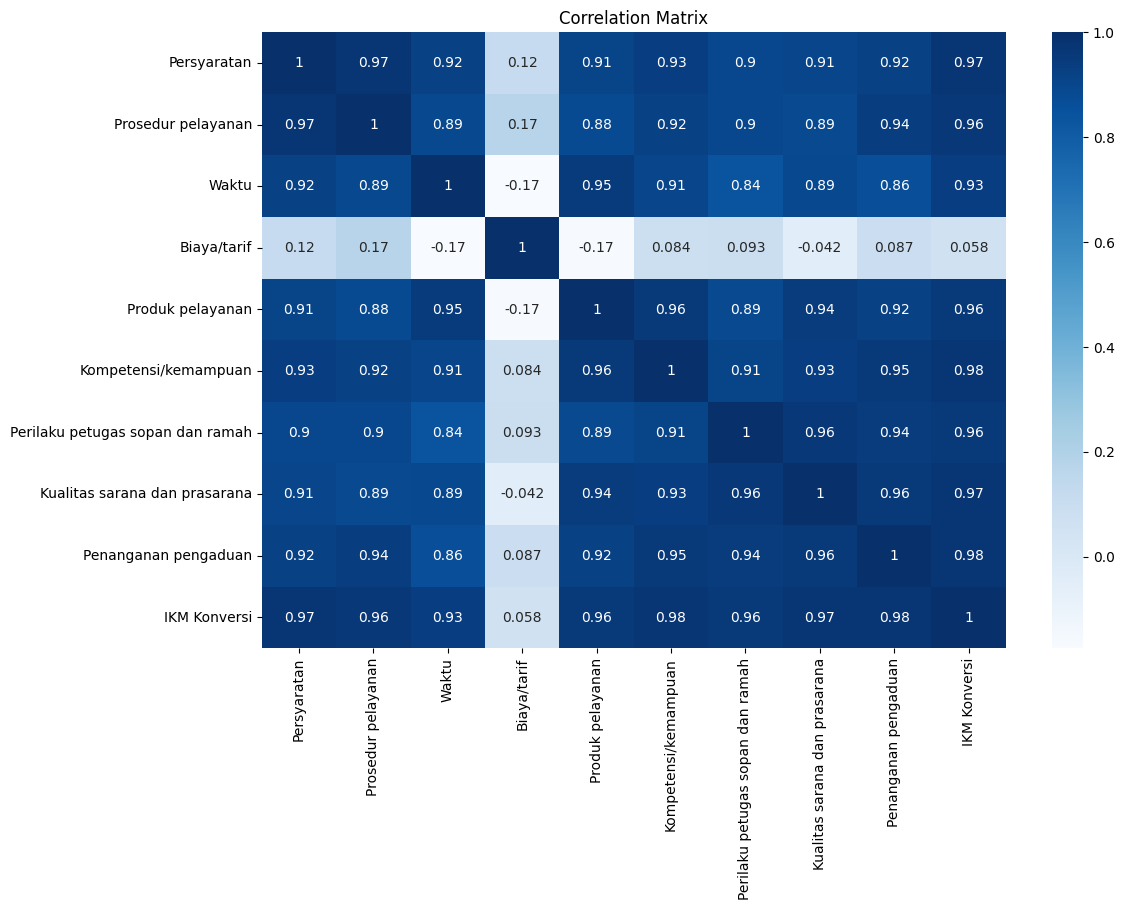

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[kolom_numerik].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")
plt.show()

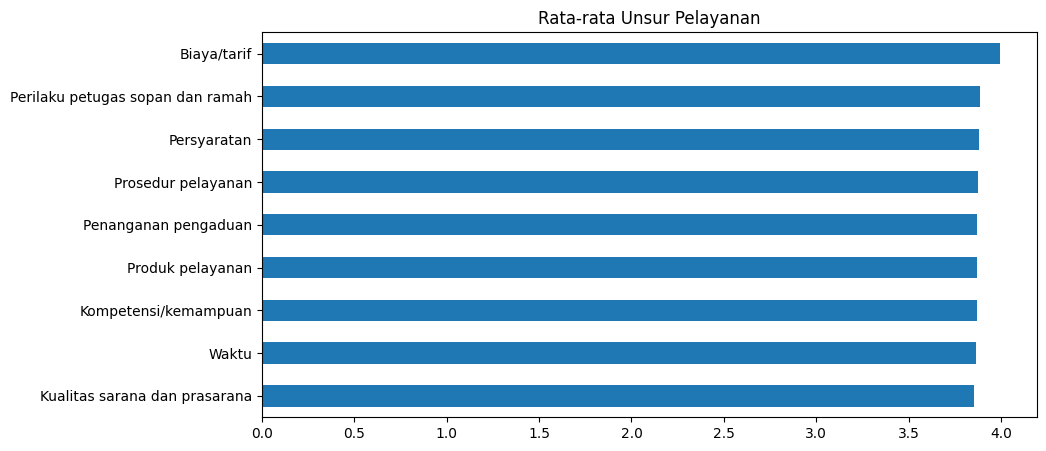

In [11]:
fitur = [
    'Persyaratan',
    'Prosedur pelayanan',
    'Waktu',
    'Biaya/tarif',
    'Produk pelayanan',
    'Kompetensi/kemampuan',
    'Perilaku petugas sopan dan ramah',
    'Kualitas sarana dan prasarana',
    'Penanganan pengaduan'
]

rata_rata = df[fitur].mean()

plt.figure(figsize=(10,5))

rata_rata.sort_values().plot(kind='barh')

plt.title("Rata-rata Unsur Pelayanan")
plt.show()

In [12]:
X = df[
    [
        'Persyaratan',
        'Prosedur pelayanan',
        'Waktu',
        'Biaya/tarif',
        'Produk pelayanan',
        'Kompetensi/kemampuan',
        'Perilaku petugas sopan dan ramah',
        'Kualitas sarana dan prasarana',
        'Penanganan pengaduan'
    ]
]

y = df['IKM Konversi']

In [13]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

Ridge()

In [16]:
y_pred = ridge.predict(X_test_scaled)

In [18]:
mae = mean_absolute_error(
    y_test,
    y_pred
)
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)
mape = np.mean(
    np.abs(
        (y_test - y_pred)
        / y_test
    )
) * 100
r2 = r2_score(
    y_test,
    y_pred
)
print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("MAPE:", round(mape,2),"%")
print("R2  :", round(r2,3))


MAE : 0.025
RMSE: 0.027
MAPE: 0.03 %
R2  : 0.999


In [19]:
hasil = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

hasil

,Aktual,Prediksi
29,98.82,98.814667
30,98.12,98.138906
31,99.05,99.085545
32,97.44,97.397959
33,96.23,96.194203
34,98.37,98.348833
35,98.44,98.461526
36,99.39,99.409952


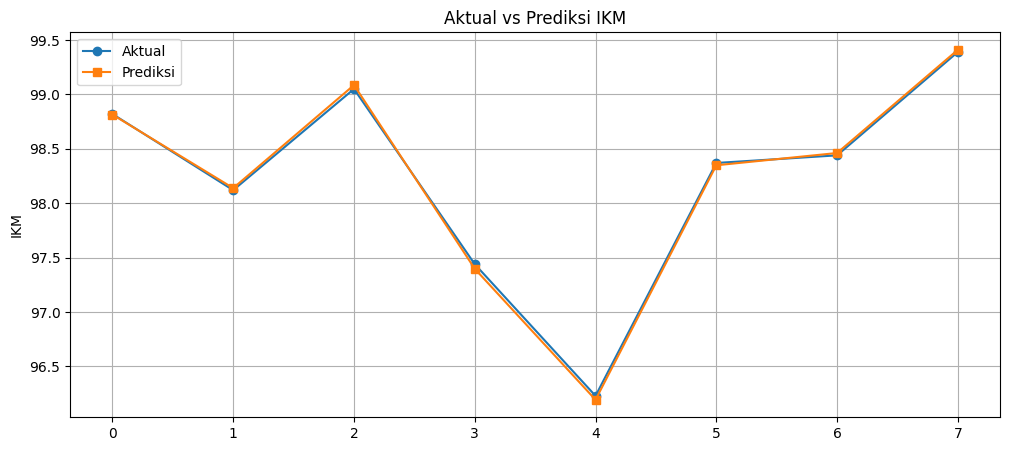

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    marker='o',
    label='Aktual'
)

plt.plot(
    y_pred,
    marker='s',
    label='Prediksi'
)

plt.title('Aktual vs Prediksi IKM')
plt.ylabel('IKM')
plt.legend()
plt.grid(True)

plt.show()